# 03b — Satellite-Derived Roughness: Alternative Methods

This notebook explores improved approaches for deriving bottom roughness from satellite imagery,
building on the threshold-based classification in notebook 01_input_satellite_roughness.

**Methods tested:**
1. **Lyzenga water column correction + Random Forest** on Sentinel-2 (10 m)
2. **PlanetScope multi-temporal compositing + RF** (3 m, seasonal)
3. **Baptist trachytopes** — converting SAV maps to depth-dependent drag for Delft3D FM

**Literature basis:** see `docs/satellite_roughness_review.md` for the full review.

**Key references:**
- Traganos & Reinartz (2018) — Sentinel-2 + Lyzenga for *P. oceanica* / *C. nodosa*
- Poursanidis et al. (2019) — RF + water column correction, Mediterranean
- Zhu et al. (2021) — Delft3D + Baptist vegetation module for seasonal seagrass effects
- Baptist et al. (2007) — analytical drag formulation implemented in Delft3D

## 1. Setup

In [6]:
%matplotlib inline
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

project_root = Path(r'C:\Users\Unipa\Documents\StagnoneDT')
sat_dir = project_root / 'data' / 'raw' / 'satellite'
model_dir = project_root / 'model' / 'dflowfm_v03c'
fig_dir = project_root / 'figures'
os.makedirs(sat_dir, exist_ok=True)

# Stagnone bounding box
LON_MIN, LON_MAX = 12.41, 12.49
LAT_MIN, LAT_MAX = 37.81, 37.92
BBOX = [LON_MIN, LAT_MIN, LON_MAX, LAT_MAX]

# Current roughness map (notebook 03 baseline)
ROUGHNESS_MAP = {0: 0.020, 1: 0.035, 2: 0.050, 3: 0.028}
CLASS_NAMES = {0: 'Bare sand/mud', 1: 'Sparse Cymodocea', 2: 'Dense Posidonia', 3: 'Rock'}

print(f'Project root: {project_root}')
print(f'Model dir:    {model_dir}')

Project root: C:\Users\Unipa\Documents\StagnoneDT
Model dir:    C:\Users\Unipa\Documents\StagnoneDT\model\dflowfm_v03c


---
## 2. Method 1 — Lyzenga Water Column Correction + Random Forest

The current notebook 01_input_satellite_roughness classifies directly on surface reflectance, which mixes bottom signal
with water column attenuation. The Lyzenga (1978, 2006) depth-invariant index (DII) removes
the water column effect, isolating bottom reflectance.

**Pipeline:**
1. Load Sentinel-2 bands (same scene as nb 01_input_satellite_roughness, or multiple)
2. Identify deep-water pixels for attenuation coefficient estimation
3. Compute depth-invariant indices (DII) for band pairs
4. Train Random Forest on DIIs + spectral indices using training polygons
5. Classify and compare with threshold approach

**Ref:** Traganos & Reinartz (2018), Poursanidis et al. (2019)

### 2.1 Load Sentinel-2 bands

Reuses the downloaded scene from notebook 01_input_satellite_roughness. If not available, run nb 01_input_satellite_roughness cells 2–3 first.

In [12]:
import rasterio
from rasterio.windows import from_bounds
from rasterio.crs import CRS
from rasterio.warp import transform_bounds, transform as warp_transform
import glob

def load_band_cropped(filepath, bbox_wgs84):
    """Load a Sentinel-2 band cropped to bounding box."""
    with rasterio.open(filepath) as src:
        left, bottom, right, top = transform_bounds(
            CRS.from_epsg(4326), src.crs, *bbox_wgs84)
        window = from_bounds(left, bottom, right, top, src.transform)
        data = src.read(1, window=window).astype(float) / 10000  # DN to reflectance
        tfm = src.window_transform(window)
        crs = src.crs
    return data, tfm, crs

# Find extracted bands from nb 03
extract_dir = sat_dir / 'extracted'
band_names = ['B02', 'B03', 'B04', 'B05', 'B08']
bands = {}

for bn in band_names:
    matches = glob.glob(str(extract_dir / '**' / f'*_{bn}_*.jp2'), recursive=True)
    res10 = [m for m in matches if '10m' in m]
    res20 = [m for m in matches if '20m' in m]
    path = res10[0] if res10 else (res20[0] if res20 else None)
    if path:
        bands[bn], tfm_utm, crs_utm = load_band_cropped(path, BBOX)
        print(f'  {bn}: {bands[bn].shape} from {os.path.basename(path)}')
    else:
        print(f'  {bn}: NOT FOUND — run notebook 03 cells 2-3 first')

blue, green, red, nir = bands['B02'], bands['B03'], bands['B04'], bands['B08']
print(f'\nAll bands loaded. Shape: {blue.shape}, CRS: {crs_utm}')

  B02: (1230, 737) from T33STB_20240926T100029_B02_10m.jp2
  B03: (1230, 737) from T33STB_20240926T100029_B03_10m.jp2
  B04: (1230, 737) from T33STB_20240926T100029_B04_10m.jp2
  B05: (615, 369) from T33STB_20240926T100029_B05_20m.jp2
  B08: (1230, 737) from T33STB_20240926T100029_B08_10m.jp2

All bands loaded. Shape: (1230, 737), CRS: EPSG:32633


### 2.2 Lyzenga Depth-Invariant Index (DII)

The DII for a band pair (i, j) removes depth dependence:

$$DII_{ij} = \ln(L_i) - \frac{k_i}{k_j} \ln(L_j)$$

where $k_i/k_j$ is estimated from the covariance of log-transformed radiance
over a uniform sandy bottom at varying depths (Lyzenga 1978).

In [13]:
def estimate_ki_kj(band_i, band_j, sand_mask):
    """Estimate attenuation ratio ki/kj from sand pixels at varying depths.
    Uses the covariance method (Lyzenga 1978, Eq. 7).
    """
    xi = np.log(band_i[sand_mask] + 1e-6)
    xj = np.log(band_j[sand_mask] + 1e-6)
    cov_matrix = np.cov(xi, xj)
    var_i = cov_matrix[0, 0]
    var_j = cov_matrix[1, 1]
    cov_ij = cov_matrix[0, 1]
    a = var_i - var_j
    ki_kj = (a + np.sqrt(a**2 + 4 * cov_ij**2)) / (2 * cov_ij)
    return ki_kj


def compute_dii(band_i, band_j, ki_kj):
    """Compute Depth-Invariant Index for band pair."""
    return np.log(band_i + 1e-6) - ki_kj * np.log(band_j + 1e-6)


# --- Identify sand calibration pixels ---
# Criteria calibrated to this scene's reflectance range:
#   blue ~0.12-0.13, green ~0.13, red ~0.12, nir ~0.11, total_rgb ~0.38
ndvi = (nir - red) / (nir + red + 1e-10)
total_refl = blue + green + red
gb_ratio_raw = green / (blue + 1e-10)

# Sand pixels: low vegetation signal, not land, moderate water depth
# - NDVI near zero (bare bottom, no vegetation)
# - GB ratio < 1.05 (vegetation pushes GB > 1.05)
# - NIR not too high (land) or too low (impossible in this scene)
# - Total reflectance in the water range for this scene
sand_mask = (
    (ndvi > -0.05) & (ndvi < 0.02) &     # no vegetation signal
    (gb_ratio_raw < 1.05) &                # not green-dominant (vegetation)
    (nir < 0.15) &                         # not land
    (total_refl > 0.33) & (total_refl < 0.42)  # shallow water range for this scene
)
print(f'Sand calibration pixels: {sand_mask.sum()} ({100*sand_mask.sum()/sand_mask.size:.1f}%)')

if sand_mask.sum() < 100:
    print('WARNING: very few sand pixels found. Relaxing thresholds...')
    sand_mask = (
        (ndvi > -0.08) & (ndvi < 0.03) &
        (gb_ratio_raw < 1.10) &
        (nir < 0.18) &
        (total_refl > 0.32) & (total_refl < 0.50)
    )
    print(f'Relaxed sand pixels: {sand_mask.sum()} ({100*sand_mask.sum()/sand_mask.size:.1f}%)')

# Compute ki/kj ratios for key band pairs
pairs = [
    ('B02', 'B03', blue, green),
    ('B02', 'B04', blue, red),
    ('B03', 'B04', green, red),
]
dii_images = {}
for name_i, name_j, bi, bj in pairs:
    ratio = estimate_ki_kj(bi, bj, sand_mask)
    dii = compute_dii(bi, bj, ratio)
    key = f'DII_{name_i}_{name_j}'
    dii_images[key] = dii
    print(f'  {key}: ki/kj = {ratio:.3f}')

print(f'\n{len(dii_images)} depth-invariant indices computed.')

Sand calibration pixels: 520426 (57.4%)
  DII_B02_B03: ki/kj = 0.313
  DII_B02_B04: ki/kj = 0.303
  DII_B03_B04: ki/kj = 1.443

3 depth-invariant indices computed.


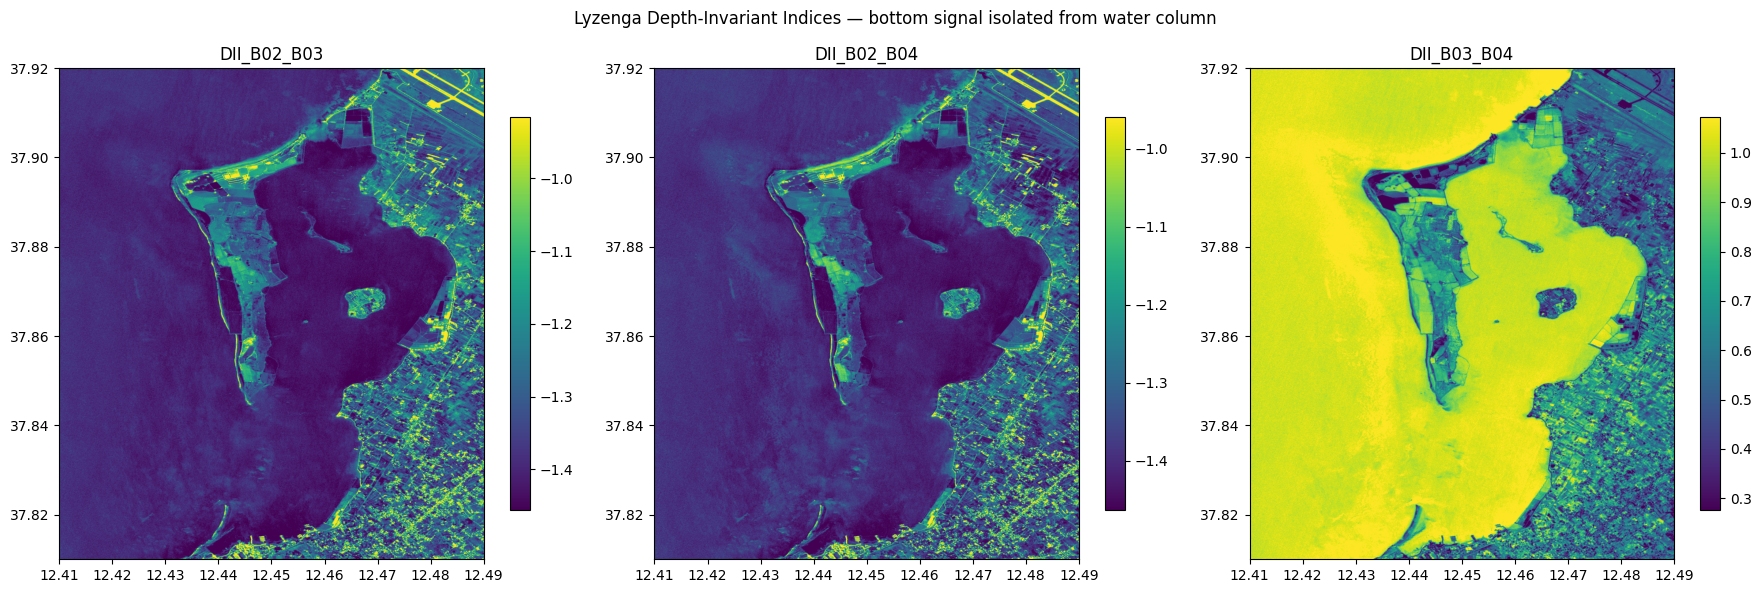

In [14]:
# Visualize DIIs
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, (key, img) in zip(axes, dii_images.items()):
    vmin, vmax = np.nanpercentile(img[~sand_mask & (total_refl > 0.02)], [2, 98])
    im = ax.imshow(img, extent=[LON_MIN, LON_MAX, LAT_MIN, LAT_MAX],
                   cmap='viridis', vmin=vmin, vmax=vmax, aspect='auto')
    ax.set_title(key)
    plt.colorbar(im, ax=ax, shrink=0.8)
fig.suptitle('Lyzenga Depth-Invariant Indices — bottom signal isolated from water column')
fig.tight_layout()
plt.show()

### 2.3 Interactive Training Polygons (ipyleaflet)

Draw training polygons on an interactive map with satellite imagery as reference.
Polygons persist to `data/processed/training_polygons_03b.geojson`, so
kernel restarts reload previously drawn regions.

**Workflow:**
1. Run the map cell below — installs `ipyleaflet` if missing.
2. Pick a class from the dropdown (top-right of the map).
3. Use the polygon or rectangle draw tool (left side of the map) to trace a
   training region. Repeat for all 4 classes; aim for ≥3 polygons per class.
4. Click **Save polygons** (bottom-right) to persist. Re-run the following
   cell to rasterize the GeoJSON into `train_X` / `train_y`.

**Map layers:**
- Esri WorldImagery basemap (high-res satellite)
- Sentinel-2 RGB overlay (optional, semi-transparent) — same scene analyzed above

In [23]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix

# --- Build feature stack ---
ndavi = (nir - blue) / (nir + blue + 1e-10)
gb_ratio = green / (blue + 1e-10)

feature_names = list(dii_images.keys()) + ['NDVI', 'NDAVI', 'GB_ratio']
feature_stack = np.stack(
    list(dii_images.values()) + [ndvi, ndavi, gb_ratio],
    axis=-1
)
print(f'Feature stack: {feature_stack.shape} ({len(feature_names)} features)')
print(f'Features: {feature_names}')

Feature stack: (1230, 737, 6) (6 features)
Features: ['DII_B02_B03', 'DII_B02_B04', 'DII_B03_B04', 'NDVI', 'NDAVI', 'GB_ratio']


In [21]:
# --- Interactive training polygon map (ipyleaflet) ---
import importlib, subprocess, sys
for pkg in ['ipyleaflet', 'ipywidgets']:
    try:
        importlib.import_module(pkg)
    except ImportError:
        print(f'Installing {pkg}...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

import base64, copy, json
from ipyleaflet import (Map, DrawControl, WidgetControl, ImageOverlay,
                         GeoJSON, basemaps, basemap_to_tiles)
import ipywidgets as widgets
from IPython.display import display
from rasterio.warp import reproject, Resampling
from rasterio.transform import from_bounds as rio_from_bounds

poly_path = project_root / 'data' / 'processed' / 'training_polygons_03b.geojson'
poly_path.parent.mkdir(parents=True, exist_ok=True)

# --- Per-class visual colors (match the classification colormap downstream) ---
CLASS_COLORS = {
    0: '#F5DEB3',  # Bare sand/mud — beige
    1: '#90EE90',  # Sparse Cymodocea — light green
    2: '#006400',  # Dense Posidonia — dark green
    3: '#808080',  # Rock/hard bottom — gray
}

# --- Export the S2 RGB as a WGS84-georeferenced PNG overlay ---
rgb_overlay_path = fig_dir / 's2_stagnone_rgb_overlay.png'
cols_out = 1200
rows_out = int(cols_out * (LAT_MAX - LAT_MIN) / (LON_MAX - LON_MIN))
dst_transform = rio_from_bounds(LON_MIN, LAT_MIN, LON_MAX, LAT_MAX, cols_out, rows_out)
rgb_wgs = np.zeros((rows_out, cols_out, 3), dtype=np.float32)
for i, band in enumerate([red, green, blue]):
    out = np.zeros((rows_out, cols_out), dtype=np.float32)
    reproject(
        source=band.astype(np.float32),
        destination=out,
        src_transform=tfm_utm,
        src_crs=crs_utm,
        dst_transform=dst_transform,
        dst_crs='EPSG:4326',
        resampling=Resampling.bilinear,
    )
    rgb_wgs[:, :, i] = out
rgb_wgs = np.clip(rgb_wgs * 3, 0, 1)
plt.imsave(str(rgb_overlay_path), rgb_wgs)
print(f'Wrote overlay (WGS84, {cols_out}x{rows_out}): {rgb_overlay_path}')

# --- Map ---
map_center = ((LAT_MIN + LAT_MAX) / 2, (LON_MIN + LON_MAX) / 2)
m = Map(center=map_center, zoom=13, scroll_wheel_zoom=True)
m.layout.height = '700px'
m.add_layer(basemap_to_tiles(basemaps.Esri.WorldImagery))

with open(rgb_overlay_path, 'rb') as f:
    b64 = base64.b64encode(f.read()).decode()
m.add_layer(ImageOverlay(
    url=f'data:image/png;base64,{b64}',
    bounds=((LAT_MIN, LON_MIN), (LAT_MAX, LON_MAX)),
    opacity=0.015,
    name='S2 RGB',
))

# --- Single source of truth for features (deep-copied at draw time) ---
features = []


def style_by_class(feat):
    cls = feat.get('properties', {}).get('class', -1)
    color = CLASS_COLORS.get(cls, '#ffff00')
    return {'color': color, 'fillColor': color, 'weight': 2, 'fillOpacity': 0.35}


saved_layer = None
if poly_path.exists():
    with open(poly_path) as f:
        saved = json.load(f)
    features.extend(saved.get('features', []))
    if features:
        saved_layer = GeoJSON(
            data={'type': 'FeatureCollection', 'features': features},
            style_callback=style_by_class,
            name='Saved polygons',
        )
        m.add_layer(saved_layer)
        print(f'Loaded {len(features)} previously saved polygons (colored by class).')

class_selector = widgets.Dropdown(
    options=[(f'{k} — {v}', k) for k, v in CLASS_NAMES.items()],
    value=0,
    description='Class:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='260px'),
)

status = widgets.HTML(value=f'<b>Polygons: {len(features)}</b>')


def shape_options_for(cls):
    color = CLASS_COLORS[int(cls)]
    return {'shapeOptions': {'color': color, 'fillColor': color,
                              'weight': 2, 'fillOpacity': 0.35}}


dc = DrawControl(
    polygon=shape_options_for(class_selector.value),
    rectangle=shape_options_for(class_selector.value),
    marker={}, circle={}, circlemarker={}, polyline={},
    edit=False, remove=True,
)


def on_class_change(change):
    # Update draw color live when the dropdown changes
    if change.get('name') != 'value':
        return
    opts = shape_options_for(change['new'])
    dc.polygon = opts
    dc.rectangle = opts


class_selector.observe(on_class_change, names='value')


def on_draw(target, action, geo_json):
    if action != 'created':
        return
    feat = copy.deepcopy(geo_json)
    feat['properties'] = dict(feat.get('properties') or {})
    feat['properties']['class'] = int(class_selector.value)
    features.append(feat)
    cls = feat['properties']['class']
    status.value = (f'<b>Polygons: {len(features)}</b>  '
                    f'(last: class {cls} — {CLASS_NAMES[cls]})')


dc.on_draw(on_draw)

save_btn = widgets.Button(description='Save polygons', icon='save',
                          button_style='success')
clear_btn = widgets.Button(description='Clear all', icon='trash',
                           button_style='danger')


def on_save(_):
    gj = {'type': 'FeatureCollection', 'features': features}
    with open(poly_path, 'w') as f:
        json.dump(gj, f, indent=2)
    counts = {c: 0 for c in CLASS_NAMES}
    for f_ in features:
        c = f_.get('properties', {}).get('class')
        if c in counts:
            counts[c] += 1
    summary = '  '.join(f'{c}:{n}' for c, n in counts.items())
    status.value = f'<b>Saved {len(features)} polygons</b> ({summary}) → {poly_path.name}'


def on_clear(_):
    features.clear()
    try:
        dc.clear()
    except Exception:
        pass
    status.value = '<b>Cleared (not saved yet — click Save to persist).</b>'


save_btn.on_click(on_save)
clear_btn.on_click(on_clear)

m.add_control(dc)
m.add_control(WidgetControl(widget=class_selector, position='topright'))
m.add_control(WidgetControl(
    widget=widgets.VBox([save_btn, clear_btn, status]),
    position='bottomright',
))

print(f'Polygons file: {poly_path}')
print('Colors:  0=beige (sand), 1=light green (Cymodocea), '
      '2=dark green (Posidonia), 3=gray (rock)')
display(m)

Wrote overlay (WGS84, 1200x1649): C:\Users\Unipa\Documents\StagnoneDT\figures\s2_stagnone_rgb_overlay.png
Loaded 26 previously saved polygons (colored by class).
Polygons file: C:\Users\Unipa\Documents\StagnoneDT\data\processed\training_polygons_03b.geojson
Colors:  0=beige (sand), 1=light green (Cymodocea), 2=dark green (Posidonia), 3=gray (rock)


Map(center=[37.865, 12.45], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_…

In [24]:
# --- Rasterize GeoJSON training polygons → train_X, train_y ---
from rasterio.features import rasterize
from rasterio.warp import transform_geom
from shapely.geometry import shape

# Keep the pixel-index helper around (used by other cells)
from rasterio.transform import rowcol
from rasterio.warp import transform as warp_tf

def lonlat_to_rowcol(lon, lat):
    x_utm, y_utm = warp_tf(CRS.from_epsg(4326), crs_utm, [lon], [lat])
    r, c = rowcol(tfm_utm, x_utm[0], y_utm[0])
    return int(r), int(c)


if not poly_path.exists():
    raise FileNotFoundError(
        f'{poly_path} not found. Draw polygons in the map cell above and click '
        '"Save polygons" first.'
    )

with open(poly_path) as f:
    gj = json.load(f)

# Reproject each polygon WGS84 → UTM (native raster CRS) before rasterizing
shapes_with_class = []
for feat in gj.get('features', []):
    props = feat.get('properties', {}) or {}
    cls = props.get('class')
    if cls is None:
        continue
    geom_utm = transform_geom('EPSG:4326', crs_utm.to_string(), feat['geometry'])
    shapes_with_class.append((shape(geom_utm), int(cls)))

if not shapes_with_class:
    raise ValueError('No polygons with a "class" property found in the GeoJSON.')

# Rasterize; 255 = unlabeled background
class_mask = rasterize(
    shapes=shapes_with_class,
    out_shape=blue.shape,
    transform=tfm_utm,
    fill=255,
    dtype=np.uint8,
)

# Extract feature vectors at labeled pixels
labeled = class_mask != 255
train_y_all = class_mask[labeled].astype(int)
train_X_all = feature_stack[labeled]

valid = ~np.any(np.isnan(train_X_all) | np.isinf(train_X_all), axis=1)
train_X = train_X_all[valid]
train_y = train_y_all[valid]

print(f'Rasterized {len(shapes_with_class)} polygons → {len(train_y)} labeled pixels')
for cls in sorted(CLASS_NAMES.keys()):
    n = int((train_y == cls).sum())
    print(f'  Class {cls} ({CLASS_NAMES[cls]}): {n} samples')

min_per_class = min(int((train_y == c).sum()) for c in CLASS_NAMES)
if min_per_class < 30:
    print(f'\nWARNING: smallest class has only {min_per_class} samples — '
          'add more polygons for this class and re-run the save button + this cell.')

Rasterized 29 polygons → 846 labeled pixels
  Class 0 (Bare sand/mud): 80 samples
  Class 1 (Sparse Cymodocea): 379 samples
  Class 2 (Dense Posidonia): 346 samples
  Class 3 (Rock): 41 samples


In [25]:
# --- Train and evaluate Random Forest ---
clf = RandomForestClassifier(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(clf, train_X, train_y, cv=cv, scoring='accuracy')
print(f'5-fold CV accuracy: {scores.mean():.3f} +/- {scores.std():.3f}')

# Train on all data
clf.fit(train_X, train_y)

# Feature importance
print('\nFeature importance:')
for name, imp in sorted(zip(feature_names, clf.feature_importances_), key=lambda x: -x[1]):
    print(f'  {name:20s}: {imp:.3f}')

5-fold CV accuracy: 0.888 +/- 0.022

Feature importance:
  DII_B03_B04         : 0.213
  DII_B02_B03         : 0.186
  DII_B02_B04         : 0.176
  NDAVI               : 0.172
  NDVI                : 0.126
  GB_ratio            : 0.126


In [26]:
# --- Predict over full image ---
flat_features = feature_stack.reshape(-1, len(feature_names))
valid_mask = ~np.any(np.isnan(flat_features) | np.isinf(flat_features), axis=1)

# Mask land (high NIR) — no deep water mask needed for this shallow lagoon scene
land_mask_flat = (nir.ravel() > 0.20)
predict_mask = valid_mask & ~land_mask_flat

rf_classes = np.full(flat_features.shape[0], -1, dtype=np.int8)
rf_classes[predict_mask] = clf.predict(flat_features[predict_mask])
rf_classes = rf_classes.reshape(blue.shape)

print(f'Classified {predict_mask.sum()} pixels ({100*predict_mask.sum()/predict_mask.size:.1f}%)')
for cls in sorted(CLASS_NAMES.keys()):
    n = (rf_classes == cls).sum()
    print(f'  Class {cls} ({CLASS_NAMES[cls]}): {n} pixels')

Classified 634233 pixels (70.0%)
  Class 0 (Bare sand/mud): 41600 pixels
  Class 1 (Sparse Cymodocea): 189273 pixels
  Class 2 (Dense Posidonia): 391414 pixels
  Class 3 (Rock): 11946 pixels


FM raster shape: (4261, 5398)  (expected ~4261x5398 from transform)
tfm_fm origin (UTM NW corner): (231980.5, 4217946.5)
S2 valid coverage (WGS84): lon 11.951-12.572, lat 37.686-37.922


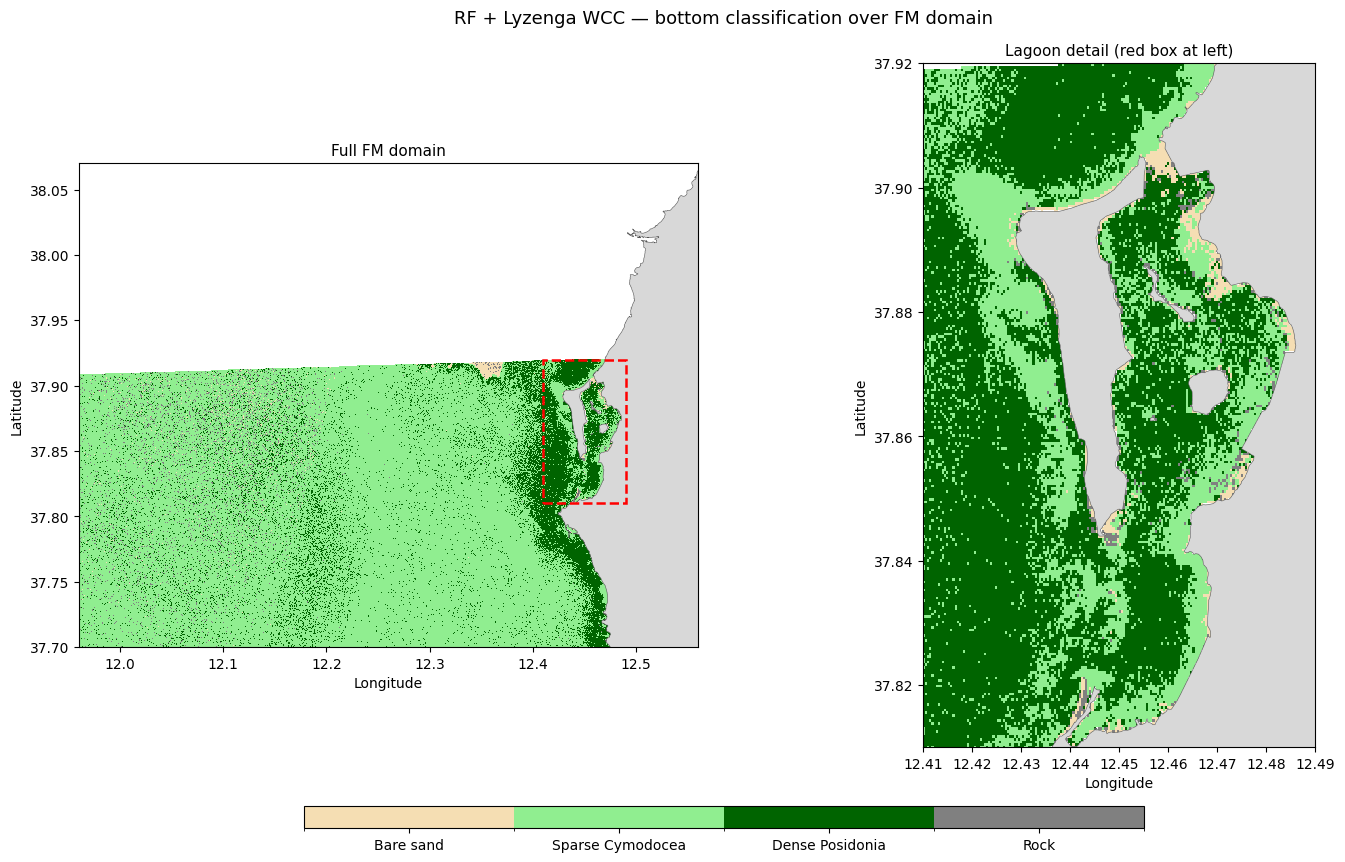

In [27]:
# --- Classify the full FM domain + lagoon zoom ---
# IMPORTANT FIX: the original `load_band_cropped` calls rasterio.read(window=...)
# without `boundless=True`. When the requested window extends beyond the source
# tile (which happens with FM_BBOX over T33STB), rasterio silently CLIPS the
# read to the tile intersection — but `window_transform(window)` still returns
# the transform for the full virtual window. Result: the array's (0,0) pixel
# corresponds to the tile's top-left, NOT to the window's top-left — a
# multi-kilometre shift. We re-read here with boundless=True so the returned
# array has the full requested shape and the transform matches every pixel.
import glob
import matplotlib.patches as mpatches
from matplotlib.collections import PatchCollection
from rasterio.features import rasterize
from rasterio.warp import transform_geom, reproject, Resampling, transform_bounds as rio_tfm_bnds
from rasterio.transform import from_bounds as rio_from_bounds
from rasterio.windows import from_bounds as rio_window_from_bounds
import rasterio as _rio
from shapely.geometry import Polygon, shape as shp_shape


def load_band_boundless(filepath, bbox_wgs84):
    """Like load_band_cropped but uses boundless=True so the returned array
    always matches the window shape (no silent clipping when the window
    extends beyond the tile)."""
    with _rio.open(filepath) as src:
        left, bottom, right, top = rio_tfm_bnds(
            CRS.from_epsg(4326), src.crs, *bbox_wgs84)
        window = rio_window_from_bounds(left, bottom, right, top, src.transform)
        data = src.read(1, window=window, boundless=True,
                        fill_value=0).astype(float) / 10000
        tfm = src.window_transform(window)
    return data, tfm, src.crs if False else None, window  # signature tweak below


# Clean loader (returns data, transform, crs)
def _load_band(filepath, bbox_wgs84):
    with _rio.open(filepath) as src:
        left, bottom, right, top = rio_tfm_bnds(
            CRS.from_epsg(4326), src.crs, *bbox_wgs84)
        window = rio_window_from_bounds(left, bottom, right, top, src.transform)
        data = src.read(1, window=window, boundless=True,
                        fill_value=0).astype(float) / 10000
        tfm = src.window_transform(window)
        crs = src.crs
    return data, tfm, crs


FM_LON_MIN, FM_LON_MAX = 11.96, 12.56
FM_LAT_MIN, FM_LAT_MAX = 37.70, 38.07
FM_BBOX = [FM_LON_MIN, FM_LAT_MIN, FM_LON_MAX, FM_LAT_MAX]

# --- Reload S2 bands for the FM domain (boundless!) ---
bands_fm = {}
for bn in ['B02', 'B03', 'B04', 'B08']:
    matches = glob.glob(str(extract_dir / '**' / f'*_{bn}_*.jp2'), recursive=True)
    paths = [m for m in matches if '10m' in m]
    if not paths:
        raise FileNotFoundError(f'10 m band {bn} not found')
    bands_fm[bn], tfm_fm, crs_fm = _load_band(paths[0], FM_BBOX)
blue_fm, green_fm, red_fm, nir_fm = (bands_fm['B02'], bands_fm['B03'],
                                     bands_fm['B04'], bands_fm['B08'])

# Sanity: compare shape vs what the transform expects for FM_BBOX
utm_w, utm_s, utm_e, utm_n = rio_tfm_bnds(CRS.from_epsg(4326), crs_fm, *FM_BBOX)
expected_cols = round((utm_e - utm_w) / tfm_fm.a)
expected_rows = round((utm_n - utm_s) / -tfm_fm.e)
print(f'FM raster shape: {blue_fm.shape}  (expected ~{expected_rows}x{expected_cols} from transform)')
print(f'tfm_fm origin (UTM NW corner): ({tfm_fm.c:.1f}, {tfm_fm.f:.1f})')

# --- Detect actual S2 coverage (pixels with all-zero bands = outside tile) ---
no_s2_data = (blue_fm == 0) & (green_fm == 0) & (red_fm == 0) & (nir_fm == 0)
valid_rows = np.where(~np.all(no_s2_data, axis=1))[0]
valid_cols = np.where(~np.all(no_s2_data, axis=0))[0]
if valid_rows.size and valid_cols.size:
    r0, r1 = int(valid_rows[0]), int(valid_rows[-1])
    c0, c1 = int(valid_cols[0]), int(valid_cols[-1])
    from rasterio.transform import xy
    xn, yn = xy(tfm_fm, r0, c0, offset='ul')
    xs, ys = xy(tfm_fm, r1 + 1, c1 + 1, offset='ul')
    lon_w, lat_s, lon_e, lat_n = rio_tfm_bnds(
        crs_fm, 'EPSG:4326', min(xn, xs), min(yn, ys), max(xn, xs), max(yn, ys)
    )
    S2_VALID_EXTENT = (lon_w, lat_s, lon_e, lat_n)
else:
    S2_VALID_EXTENT = tuple(FM_BBOX)
print(f'S2 valid coverage (WGS84): lon {S2_VALID_EXTENT[0]:.3f}-{S2_VALID_EXTENT[2]:.3f}, '
      f'lat {S2_VALID_EXTENT[1]:.3f}-{S2_VALID_EXTENT[3]:.3f}')

# --- DIIs with LAGOON ki/kj ---
dii_fm = {}
for name_i, name_j, bi_fm_, bj_fm_, bi_lag, bj_lag in [
    ('B02', 'B03', blue_fm, green_fm, blue, green),
    ('B02', 'B04', blue_fm, red_fm,   blue, red),
    ('B03', 'B04', green_fm, red_fm,  green, red),
]:
    ratio = estimate_ki_kj(bi_lag, bj_lag, sand_mask)
    dii_fm[f'DII_{name_i}_{name_j}'] = compute_dii(bi_fm_, bj_fm_, ratio)

ndvi_fm = (nir_fm - red_fm) / (nir_fm + red_fm + 1e-10)
ndavi_fm = (nir_fm - blue_fm) / (nir_fm + blue_fm + 1e-10)
gb_ratio_fm = green_fm / (blue_fm + 1e-10)
feature_stack_fm = np.stack(
    list(dii_fm.values()) + [ndvi_fm, ndavi_fm, gb_ratio_fm], axis=-1
)

flat_fm = feature_stack_fm.reshape(-1, feature_stack_fm.shape[-1])
valid_fm = ~np.any(np.isnan(flat_fm) | np.isinf(flat_fm), axis=1)
valid_fm &= ~no_s2_data.ravel()
rf_fm = np.full(flat_fm.shape[0], -1, dtype=np.int8)
rf_fm[valid_fm] = clf.predict(flat_fm[valid_fm])
rf_fm = rf_fm.reshape(blue_fm.shape)

# --- Parse .ldb polylines ---
def parse_ldb(path):
    out = []
    with open(path) as fh:
        toks = [ln.strip() for ln in fh
                if ln.strip() and not ln.strip().startswith('*')]
    i = 0
    while i < len(toks):
        name = toks[i]; i += 1
        if i >= len(toks): break
        try:
            n_pts, _ = map(int, toks[i].split())
        except ValueError:
            break
        i += 1
        coords = []
        for k in range(n_pts):
            if i + k >= len(toks): break
            parts = toks[i + k].split()
            if len(parts) >= 2:
                try:
                    coords.append([float(parts[0]), float(parts[1])])
                except ValueError:
                    pass
        i += n_pts
        arr = np.array(coords) if coords else np.empty((0, 2))
        if arr.size == 0:
            continue
        arr = arr[np.all(np.isfinite(arr), axis=1) & ~np.any(np.abs(arr) > 900, axis=1)]
        if len(arr) >= 3:
            out.append((name, arr))
    return out

polylines = []
for ldb_name in ['sicily2.ldb', 'Stagnone_dxy01_15m.ldb']:
    p = model_dir / ldb_name
    if p.exists():
        polylines.extend(parse_ldb(p))

poly_utm_list = []
for _, coords_wgs in polylines:
    if not np.allclose(coords_wgs[0], coords_wgs[-1], atol=1e-7):
        coords_wgs = np.vstack([coords_wgs, coords_wgs[:1]])
    try:
        p_wgs = Polygon(coords_wgs)
        if not p_wgs.is_valid:
            p_wgs = p_wgs.buffer(0)
        if p_wgs.is_empty:
            continue
        p_utm = shp_shape(transform_geom('EPSG:4326', crs_fm.to_string(),
                                          p_wgs.__geo_interface__))
        if p_utm.is_valid and not p_utm.is_empty:
            poly_utm_list.append(p_utm)
    except Exception:
        continue

land_mask_fm = rasterize(
    shapes=[(g, 1) for g in poly_utm_list],
    out_shape=blue_fm.shape,
    transform=tfm_fm,
    fill=0,
    dtype=np.uint8,
).astype(bool)
rf_fm[land_mask_fm] = -1

# --- Reproject UTM → WGS84 ---
cols_dst = 1400
rows_dst = int(cols_dst * (FM_LAT_MAX - FM_LAT_MIN) / (FM_LON_MAX - FM_LON_MIN))
dst_tfm = rio_from_bounds(FM_LON_MIN, FM_LAT_MIN, FM_LON_MAX, FM_LAT_MAX,
                           cols_dst, rows_dst)
rf_wgs = np.full((rows_dst, cols_dst), -1, dtype=np.int8)
reproject(
    source=rf_fm, destination=rf_wgs,
    src_transform=tfm_fm, src_crs=crs_fm,
    dst_transform=dst_tfm, dst_crs='EPSG:4326',
    resampling=Resampling.nearest,
    src_nodata=-1, dst_nodata=-1,
)
masked_wgs = np.ma.masked_where(rf_wgs == -1, rf_wgs)

# --- Plot ---
mean_lat = (FM_LAT_MIN + FM_LAT_MAX) / 2
aspect_ratio = 1.0 / np.cos(np.radians(mean_lat))
extent_fm = [FM_LON_MIN, FM_LON_MAX, FM_LAT_MIN, FM_LAT_MAX]
cmap_class = mcolors.ListedColormap(['#F5DEB3', '#90EE90', '#006400', '#808080'])
norm = mcolors.BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5], cmap_class.N)


def make_land_patches():
    patches_ = []
    for _, coords in polylines:
        c = coords
        if not np.allclose(c[0], c[-1], atol=1e-7):
            c = np.vstack([c, c[:1]])
        patches_.append(mpatches.Polygon(c, closed=True))
    return patches_


fig = plt.figure(figsize=(15, 9))
fig.suptitle('RF + Lyzenga WCC — bottom classification over FM domain',
             fontsize=13, y=0.96)

ax_full = fig.add_subplot(1, 2, 1)
im = ax_full.imshow(masked_wgs, extent=extent_fm, cmap=cmap_class, norm=norm,
                    origin='upper', interpolation='nearest', zorder=1)
ax_full.add_collection(PatchCollection(
    make_land_patches(), facecolor='#d8d8d8', edgecolor='#555555',
    linewidth=0.4, zorder=2,
))
ax_full.set_xlim(FM_LON_MIN, FM_LON_MAX)
ax_full.set_ylim(FM_LAT_MIN, FM_LAT_MAX)
ax_full.set_aspect(aspect_ratio)
ax_full.set_title('Full FM domain', fontsize=11)
ax_full.set_xlabel('Longitude'); ax_full.set_ylabel('Latitude')
ax_full.add_patch(mpatches.Rectangle(
    (LON_MIN, LAT_MIN), LON_MAX - LON_MIN, LAT_MAX - LAT_MIN,
    linewidth=1.8, edgecolor='red', facecolor='none', linestyle='--', zorder=3,
))

ax_zoom = fig.add_subplot(1, 2, 2)
ax_zoom.imshow(masked_wgs, extent=extent_fm, cmap=cmap_class, norm=norm,
               origin='upper', interpolation='nearest', zorder=1)
ax_zoom.add_collection(PatchCollection(
    make_land_patches(), facecolor='#d8d8d8', edgecolor='#555555',
    linewidth=0.4, zorder=2,
))
ax_zoom.set_xlim(LON_MIN, LON_MAX)
ax_zoom.set_ylim(LAT_MIN, LAT_MAX)
ax_zoom.set_aspect(aspect_ratio)
ax_zoom.set_title('Lagoon detail (red box at left)', fontsize=11)
ax_zoom.set_xlabel('Longitude'); ax_zoom.set_ylabel('Latitude')

fig.subplots_adjust(left=0.07, right=0.97, top=0.90, bottom=0.14, wspace=0.18)
cbar_ax = fig.add_axes([0.22, 0.05, 0.56, 0.025])
cb = fig.colorbar(im, cax=cbar_ax, ticks=[0, 1, 2, 3], orientation='horizontal')
cb.set_ticklabels(['Bare sand', 'Sparse Cymodocea', 'Dense Posidonia', 'Rock'])

plt.savefig(str(fig_dir / 'roughness_rf_full_domain.png'),
            dpi=150, bbox_inches='tight')
plt.show()

---
## 3. Method 2 -- PlanetScope Multi-temporal Compositing

PlanetScope (3 m, near-daily) enables:
- Seasonal composites (median, percentiles) that reduce noise and sun glint
- Change detection for seagrass dynamics
- 3x better spatial resolution than Sentinel-2 for delineating Posidonia matte edges

We use 18 Planet SuperDove (PSB.SD) scenes across 9 dates (summer 2025, Jun-Sep) already
downloaded to `data/raw/satellite/planet/summer2025/`. A helper script
(`scripts/planet_mosaic_composite.py`) mosaics each date's 2-3 adjacent footprints,
applies the UDM2 clear-pixel mask, re-samples to a common EPSG:32633 grid, and
writes `data/processed/planet_composite_summer2025.nc` -- per-band (median, p10,
std) composites (~3.7 GB, gitignored).

Bands (PlanetScope SuperDove 8-band): coastal_blue, blue, green_i, green, yellow,
red, red_edge, nir.

**Ref:** Wicaksono & Lazuardi (2018), Carlson et al. (2023), Lyons et al. (2020)

In [7]:
import xarray as xr
# --- Load the pre-built PlanetScope composite ---
# Built once via: `python scripts/planet_mosaic_composite.py`
# (If the cache is missing, run that script before proceeding.)
PLANET_CACHE = project_root / 'data' / 'processed' / 'planet_composite_summer2025.nc'
if not PLANET_CACHE.exists():
    raise FileNotFoundError(
        f'{PLANET_CACHE.relative_to(project_root)} missing. '
        f'Run: python scripts/planet_mosaic_composite.py'
    )

pl = xr.open_dataset(PLANET_CACHE)
print(f'PlanetScope composite loaded:')
print(f'  dims: {dict(pl.sizes)}')
print(f'  bands: {pl.band.values.tolist()}')
print(f'  wavelengths (nm): {pl.wavelength_nm.values.tolist()}')
print(f'  n_dates: {pl.attrs["n_dates"]}  ({pl.attrs["dates"]})')
print(f'  resolution: {pl.attrs["pixel_res_m"]} m')
print(f'  UTM 33N extent (m): '
      f'x [{float(pl.x.min()):.0f}, {float(pl.x.max()):.0f}]  '
      f'y [{float(pl.y.min()):.0f}, {float(pl.y.max()):.0f}]')

PlanetScope composite loaded:
  dims: {'band': 8, 'y': 8923, 'x': 4324}
  bands: ['coastal_blue', 'blue', 'green_i', 'green', 'yellow', 'red', 'red_edge', 'nir']
  wavelengths (nm): [443, 490, 531, 565, 610, 665, 705, 865]
  n_dates: 9  (20250604,20250629,20250714,20250731,20250809,20250817,20250904,20250912,20250920)
  resolution: 3.0 m
  UTM 33N extent (m): x [270046, 283016]  y [4184210, 4210976]


### 3.1 RGB true-color preview of median composite

The median across 9 dates suppresses ephemeral artifacts (sun glint, passing boats,
brief turbidity events) and yields a clean base for bottom-type classification.

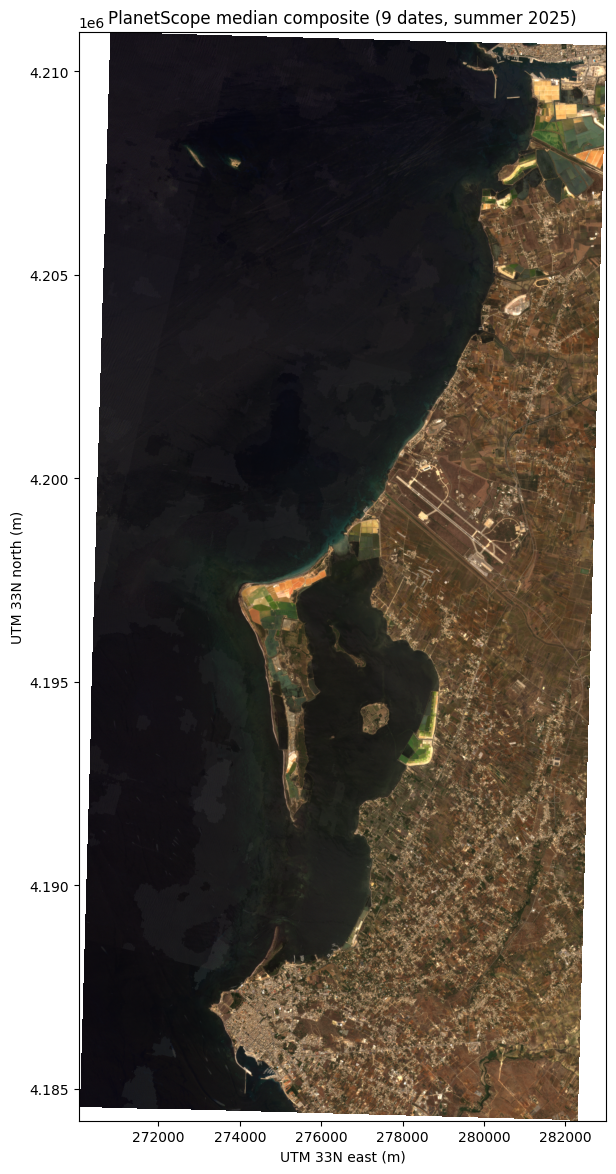

In [8]:
# Downsample for preview (full 38 Mpixel grid is too heavy to plot)
step = 4
pl_sub = pl['median'].isel(y=slice(None, None, step), x=slice(None, None, step))
rgb = np.stack([pl_sub.isel(band=5).values,   # red (665 nm)
                pl_sub.isel(band=3).values,   # green (565 nm)
                pl_sub.isel(band=1).values],  # blue (490 nm)
               axis=-1)
rgb = np.clip(rgb / 3500.0, 0, 1)  # scaled reflectance stretch

fig, ax = plt.subplots(figsize=(7, 12))
ax.imshow(rgb, extent=[float(pl_sub.x.min()), float(pl_sub.x.max()),
                       float(pl_sub.y.min()), float(pl_sub.y.max())],
          origin='upper')
ax.set_xlabel('UTM 33N east (m)')
ax.set_ylabel('UTM 33N north (m)')
ax.set_title(f'PlanetScope median composite ({pl.attrs["n_dates"]} dates, summer 2025)')
fig.tight_layout()
fig.savefig(fig_dir / 'planet_composite_rgb_preview.png', dpi=120, bbox_inches='tight')
plt.show()

### 3.2 Rasterize training polygons onto the composite grid

Training polygons live in `data/processed/training_polygons_03b.geojson` (WGS84, 26
features across 4 classes). Reproject to EPSG:32633 and burn into an integer label
raster aligned 1:1 with the composite.

In [29]:
from rasterio.features import rasterize
from rasterio.transform import from_origin
import geopandas as gpd

# Load training polygons (WGS84) and reproject to EPSG:32633
polys_wgs = gpd.read_file(project_root / 'data' / 'processed' / 'training_polygons_03b.geojson')
polys = polys_wgs.to_crs(epsg=32633)
print(f'Training polygons: {len(polys)} features')
print(polys['class'].value_counts().sort_index().rename('count').to_frame())

# Build the affine transform of the composite grid (EPSG:32633)
# x axis increases east (+), y axis decreases north (from top)
res = pl.attrs['pixel_res_m']
x0 = float(pl.x.values[0]) - res / 2   # top-left x edge
y0 = float(pl.y.values[0]) + res / 2   # top-left y edge (y decreases going down)
composite_transform = from_origin(x0, y0, res, res)

# Rasterize: class labels as uint8, 255 = no polygon
class_raster = rasterize(
    shapes=((geom, int(cls)) for geom, cls in zip(polys.geometry, polys['class'])),
    out_shape=(pl.sizes['y'], pl.sizes['x']),
    transform=composite_transform,
    fill=255,
    dtype='uint8',
)
print(f'Rasterized class_raster shape: {class_raster.shape}, dtype: {class_raster.dtype}')
for c in sorted([c for c in np.unique(class_raster) if c != 255]):
    n = int((class_raster == c).sum())
    name = CLASS_NAMES.get(c, '?')
    print(f'  class {c} ({name}): {n} training pixels')


Training polygons: 29 features
       count
class       
0         12
1          5
2          7
3          5
Rasterized class_raster shape: (8923, 4324), dtype: uint8
  class 0 (Bare sand/mud): 965 training pixels
  class 1 (Sparse Cymodocea): 4394 training pixels
  class 2 (Dense Posidonia): 3852 training pixels
  class 3 (Rock): 426 training pixels


### 3.3 Spectral signature QC of training samples

For each training class, plot the mean reflectance across the 8 PlanetScope bands ±1σ.
Well-separated classes have distinct spectral curves with moderate intra-class spread;
overlap or chaotic shapes indicate polygons that mix bottom types or stray into the wrong
cover. Use this to decide whether to redraw polygons before training.

In [ ]:
# Spectral signature per class from the training polygons
band_names_pl = list(pl.band.values)
wavs = pl.wavelength_nm.values
band_idx = np.arange(len(band_names_pl))
colors_cls = {0: '#e8c28e', 1: '#88c08a', 2: '#2a6a3c', 3: '#808080'}

fig, ax = plt.subplots(figsize=(11, 6))
for c in sorted(k for k in CLASS_NAMES):
    m = (class_raster == c)
    if m.sum() == 0:
        continue
    # Stack all 8 bands for these training pixels
    vals = np.stack([
        pl['median'].isel(band=b).values[m] / 10000.0
        for b in range(len(band_names_pl))
    ], axis=0)  # (n_bands, n_pixels)
    mean = np.nanmean(vals, axis=1)
    std  = np.nanstd(vals, axis=1)
    ax.fill_between(band_idx, mean - std, mean + std, alpha=0.20, color=colors_cls[c])
    ax.plot(band_idx, mean, '-o', color=colors_cls[c], lw=2,
            label=f'{CLASS_NAMES[c]}  (n={int(m.sum())})')
ax.set_xticks(band_idx)
ax.set_xticklabels([f'{n}
{w} nm' for n, w in zip(band_names_pl, wavs)],
                   fontsize=9)
ax.set_ylabel('Surface reflectance')
ax.set_title('Spectral signature of training polygons on PlanetScope median composite (mean +/- 1 sigma)')
ax.legend(loc='upper left')
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(fig_dir / 'planet_training_spectral_signatures.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.4 Lyzenga Depth-Invariant Index on PlanetScope 8-band

Use the training polygons' "sand-like" class (class 1 -- Sparse Cymodocea / bare
bottom) as the calibration pool to estimate attenuation ratios. With 8 Planet bands
we have 28 possible pairs; we focus on the four most water-penetrating ones:

- coastal_blue / blue   (443 / 490 nm)
- blue / green          (490 / 565 nm)
- green / red           (565 / 665 nm)
- coastal_blue / green  (443 / 565 nm)

Sand calibration pixels: 817
  DII coastal_blue/blue          ki/kj = 0.949
  DII blue/green         ki/kj = 1.101
  DII green/red           ki/kj = 1.210
  DII coastal_blue/green         ki/kj = 1.045


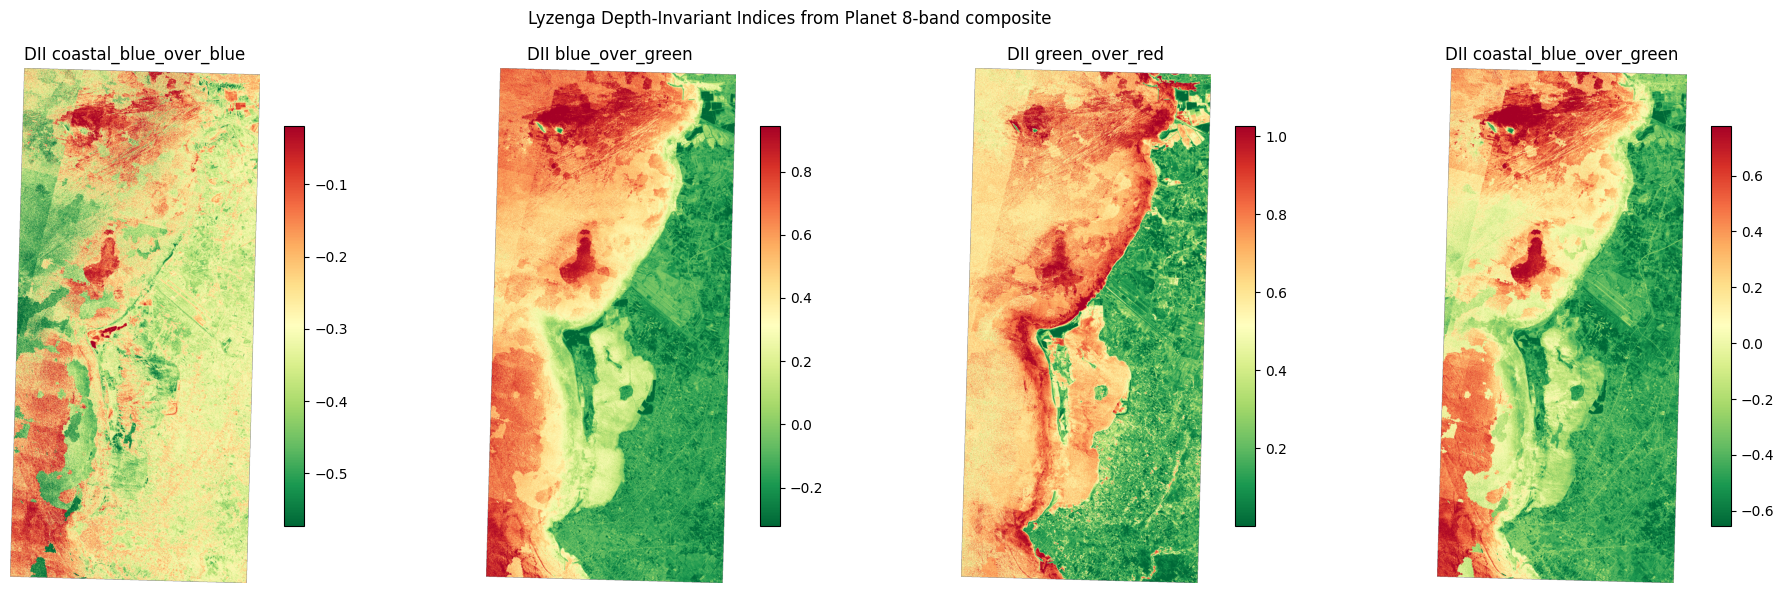

In [15]:
# Extract the 8 bands from the composite as float32 reflectance (uint16 / 10000)
# Access pattern keeps things lazy -- only materialize when we index.
SCALE = 10000.0
band_names = list(pl.band.values)
def band_arr(name: str):
    idx = band_names.index(name)
    return pl['median'].isel(band=idx).values.astype(np.float32) / SCALE

coastal_blue = band_arr('coastal_blue')
blue_pl      = band_arr('blue')
green_pl     = band_arr('green')
red_pl       = band_arr('red')

# Sand calibration mask: training polygon class 0 (Bare sand/mud) -- Lyzenga assumes
# uniform bottom type with varying depths, so Bare sand is the right calibration pool.
sand_calib = (class_raster == 0)
print(f'Sand calibration pixels: {sand_calib.sum()}')

# Guard: need enough samples
assert sand_calib.sum() >= 100, 'Too few sand pixels; widen class-1 polygons'

pairs = [
    ('coastal_blue', 'blue',   coastal_blue, blue_pl),
    ('blue',         'green',  blue_pl,      green_pl),
    ('green',        'red',    green_pl,     red_pl),
    ('coastal_blue', 'green',  coastal_blue, green_pl),
]
dii_pl = {}
for n_i, n_j, bi, bj in pairs:
    ratio = estimate_ki_kj(bi, bj, sand_calib)
    dii_pl[f'{n_i}_over_{n_j}'] = compute_dii(bi, bj, ratio)
    print(f'  DII {n_i}/{n_j:12s}  ki/kj = {ratio:.3f}')

# Quick visual: each DII side-by-side
fig, axes = plt.subplots(1, len(pairs), figsize=(20, 6))
for ax, (name, dii) in zip(axes, dii_pl.items()):
    dii_sub = dii[::4, ::4]   # downsample for plot
    im = ax.imshow(dii_sub, cmap='RdYlGn_r',
                   vmin=np.nanpercentile(dii_sub, 2),
                   vmax=np.nanpercentile(dii_sub, 98))
    ax.set_title(f'DII {name}')
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.04)
fig.suptitle('Lyzenga Depth-Invariant Indices from Planet 8-band composite')
fig.tight_layout()
fig.savefig(fig_dir / 'planet_dii_preview.png', dpi=120, bbox_inches='tight')
plt.show()


### 3.5 Feature stack + Random Forest training

Feature set (11 layers): 8 band medians + 3 best-correlated DIIs. Extract training
values at each polygon pixel, fit a Random Forest, and cross-validate.

In [30]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
import time

# Feature stack: shape (n_features, H, W)
features = np.stack([
    coastal_blue, blue_pl, green_pl, red_pl,
    band_arr('green_i'),
    band_arr('yellow'),
    band_arr('red_edge'),
    band_arr('nir'),
    dii_pl['coastal_blue_over_blue'],
    dii_pl['blue_over_green'],
    dii_pl['green_over_red'],
], axis=0).astype(np.float32)
feature_names = ['coastal_blue', 'blue', 'green', 'red', 'green_i', 'yellow',
                 'red_edge', 'nir',
                 'DII_cb_blue', 'DII_blue_green', 'DII_green_red']
print(f'Feature stack shape: {features.shape} (features, H, W)')

# Extract training pixels
train_mask = class_raster != 255
train_X = features[:, train_mask].T    # (n_samples, n_features)
train_y = class_raster[train_mask]
# Remove NaN rows (can happen at composite edges / cloud-always pixels)
finite = np.all(np.isfinite(train_X), axis=1)
train_X, train_y = train_X[finite], train_y[finite]
print(f'Training samples: {len(train_y)} -- class counts: {np.bincount(train_y)}')

# Subsample if too big (RF can be slow on 8k samples with depth>20)
rng = np.random.default_rng(0)
MAX_PER_CLASS = 1500
mask = np.zeros(len(train_y), dtype=bool)
for c in np.unique(train_y):
    idxs = np.where(train_y == c)[0]
    keep = rng.choice(idxs, size=min(len(idxs), MAX_PER_CLASS), replace=False)
    mask[keep] = True
train_X, train_y = train_X[mask], train_y[mask]
print(f'After balance: {len(train_y)} -- class counts: {np.bincount(train_y)}')

t0 = time.time()
rf_pl = RandomForestClassifier(
    n_estimators=200, max_depth=None, min_samples_leaf=2,
    class_weight='balanced', random_state=0, n_jobs=-1,
)
rf_pl.fit(train_X, train_y)
cv_acc = cross_val_score(rf_pl, train_X, train_y, cv=5, n_jobs=-1).mean()
print(f'RF fit in {time.time()-t0:.1f}s; 5-fold CV accuracy: {cv_acc:.3f}')

# Feature importance
imp = sorted(zip(feature_names, rf_pl.feature_importances_), key=lambda p: -p[1])
print()
print('Feature importance:')
for name, val in imp:
    print(f'  {name:15s}  {val:.3f}')

Feature stack shape: (11, 8923, 4324) (features, H, W)
Training samples: 9637 -- class counts: [ 965 4394 3852  426]
After balance: 4391 -- class counts: [ 965 1500 1500  426]
RF fit in 5.3s; 5-fold CV accuracy: 0.869

Feature importance:
  yellow           0.197
  green_i          0.173
  green            0.167
  red              0.136
  blue             0.108
  red_edge         0.098
  nir              0.034
  coastal_blue     0.031
  DII_green_red    0.029
  DII_blue_green   0.013
  DII_cb_blue      0.013


### 3.6 Predict on the full FM-domain extent with land boundary overlay

Predict over the whole composite (~38 Mpixels, ~1-3 min), mask land pixels using the
v03 LDB files (`sicily2.ldb` + `Stagnone_dxy01_15m.ldb` -- same ones used to mask the
Sentinel-2 classification in Section 2), and overlay the coastline polygons on the
classification map so the lagoon islands and the Trapani shoreline are visible.

The BBOX defined in the setup cell governs the quick lagoon-only iteration earlier;
the FM extent used here is larger and matches Section 2's Sentinel-2 FM-wide plot.

In [ ]:
# --- Parse LDB (coastline + islands) ---
# Same pattern as Section 2 S2 classification: build land_mask on the Planet composite
# grid and use it to blank out non-water pixels in the classification.

from shapely.geometry import Polygon, shape as shp_shape
from rasterio.warp import transform_geom


def parse_ldb(path):
    out = []
    with open(path) as fh:
        toks = [ln.strip() for ln in fh
                if ln.strip() and not ln.strip().startswith("*")]
    i = 0
    while i < len(toks):
        name = toks[i]; i += 1
        if i >= len(toks): break
        try:
            n_pts, _ = map(int, toks[i].split())
        except ValueError:
            break
        i += 1
        coords = []
        for k in range(n_pts):
            if i + k >= len(toks): break
            parts = toks[i + k].split()
            if len(parts) >= 2:
                try:
                    coords.append([float(parts[0]), float(parts[1])])
                except ValueError:
                    pass
        i += n_pts
        arr = np.array(coords) if coords else np.empty((0, 2))
        if arr.size == 0:
            continue
        arr = arr[np.all(np.isfinite(arr), axis=1) & ~np.any(np.abs(arr) > 900, axis=1)]
        if len(arr) >= 3:
            out.append((name, arr))
    return out


polylines = []
for ldb_name in ["sicily2.ldb", "Stagnone_dxy01_15m.ldb"]:
    p = model_dir / ldb_name
    if p.exists():
        polylines.extend(parse_ldb(p))
print(f"Loaded {len(polylines)} coastline/island polylines from LDB.")

# Reproject LDB polygons (WGS84) to composite CRS (EPSG:32633) and rasterize
composite_crs = "EPSG:32633"
poly_utm_list = []
for _, coords_wgs in polylines:
    if not np.allclose(coords_wgs[0], coords_wgs[-1], atol=1e-7):
        coords_wgs = np.vstack([coords_wgs, coords_wgs[:1]])
    try:
        p_wgs = Polygon(coords_wgs)
        if not p_wgs.is_valid:
            p_wgs = p_wgs.buffer(0)
        if p_wgs.is_empty:
            continue
        p_utm = shp_shape(transform_geom("EPSG:4326", composite_crs,
                                          p_wgs.__geo_interface__))
        if p_utm.is_valid and not p_utm.is_empty:
            poly_utm_list.append(p_utm)
    except Exception:
        continue
print(f"Valid reprojected polygons: {len(poly_utm_list)}")

# Rasterize land polygons on composite grid
land_mask = rasterize(
    shapes=[(g, 1) for g in poly_utm_list],
    out_shape=(pl.sizes["y"], pl.sizes["x"]),
    transform=composite_transform,
    fill=0, dtype="uint8",
).astype(bool)
print(f"Land pixels in composite: {int(land_mask.sum()):,} "
      f"({100*land_mask.mean():.1f}%)")

# --- Predict on the whole composite ---
feat_flat = features.reshape(features.shape[0], -1).T
finite_mask = np.all(np.isfinite(feat_flat), axis=1)
land_flat = land_mask.ravel()
predict_mask = finite_mask & ~land_flat
print(f"Predicting on {int(predict_mask.sum()):,} pixels "
      f"({predict_mask.sum()/1e6:.1f} Mpixels) ...")

t0 = time.time()
pred_full = np.full(len(finite_mask), 255, dtype=np.uint8)
CHUNK = 500_000
idx_to_pred = np.where(predict_mask)[0]
for i0 in range(0, len(idx_to_pred), CHUNK):
    i1 = min(len(idx_to_pred), i0 + CHUNK)
    chunk_rows = idx_to_pred[i0:i1]
    pred_full[chunk_rows] = rf_pl.predict(feat_flat[chunk_rows])
    if (i0 // CHUNK) % 4 == 0:
        print(f"  {i0/1e6:.1f}M / {len(idx_to_pred)/1e6:.1f}M done")
pred_2d_full = pred_full.reshape(pl.sizes["y"], pl.sizes["x"])
print(f"Full-extent predict done in {time.time()-t0:.1f}s")

# --- Plot: RGB + classification with coastline overlay ---
step = 4
rgb_full = np.stack([
    pl["median"].isel(band=5).values[::step, ::step],
    pl["median"].isel(band=3).values[::step, ::step],
    pl["median"].isel(band=1).values[::step, ::step],
], axis=-1)
rgb_full = np.clip(rgb_full / 3500.0, 0, 1)

extent = [pl.x.values[0], pl.x.values[-1], pl.y.values[-1], pl.y.values[0]]

fig, axes = plt.subplots(1, 2, figsize=(14, 12))
axes[0].imshow(rgb_full, extent=extent, origin="upper")
axes[0].set_title("PlanetScope median RGB (full composite)")
axes[0].set_xlabel("UTM 33N east (m)"); axes[0].set_ylabel("UTM 33N north (m)")

cmap_cls = mcolors.ListedColormap(["#F5DEB3", "#90EE90", "#006400", "#808080"])
pred_plot = np.ma.masked_equal(pred_2d_full[::step, ::step], 255)
im = axes[1].imshow(pred_plot, cmap=cmap_cls, vmin=0, vmax=3, extent=extent, origin="upper")
axes[1].set_title("Planet RF classification (land masked from LDB)")
axes[1].set_xlabel("UTM 33N east (m)")

# Coastline overlay on both panels
for ax in axes:
    for g in poly_utm_list:
        if g.geom_type == "Polygon":
            xs, ys = g.exterior.xy
            ax.plot(xs, ys, "k-", lw=0.5, alpha=0.8)
        elif g.geom_type == "MultiPolygon":
            for sub in g.geoms:
                xs, ys = sub.exterior.xy
                ax.plot(xs, ys, "k-", lw=0.5, alpha=0.8)

cbar = plt.colorbar(im, ax=axes[1], ticks=[0, 1, 2, 3], fraction=0.04)
cbar.ax.set_yticklabels([CLASS_NAMES[c] for c in range(4)])

fig.tight_layout()
fig.savefig(fig_dir / "planet_rf_classification_full.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 4. Method 3 — Baptist Trachytopes for Delft3D FM

Instead of mapping classification → fixed Manning n, the Baptist formulation computes
an effective Chezy roughness that **depends on water depth**:

$$C_b = C_{bed} + \frac{\sqrt{g}}{\kappa} \ln\left(\frac{h}{h_v}\right) \quad \text{for } h > h_v$$

where:
- $C_{bed}$ = bed Chezy (bare sediment)
- $h$ = water depth (varies with tide)
- $h_v$ = vegetation height
- $m$ = stem density (stems/m²)
- $D$ = stem diameter (m)
- $C_D$ = drag coefficient

**Key advantage**: roughness adapts dynamically to tidal water level changes.

**Ref:** Baptist et al. (2007), Zhu et al. (2021), Nepf (2012)

In [18]:
# --- Vegetation parameters from literature ---
# Sources: Nepf (2012), Zhu et al. (2021), various Med seagrass studies

veg_params = pd.DataFrame([
    {'class': 0, 'name': 'Bare sand/mud',      'h_v': 0.0,  'm': 0,    'D': 0.0,    'C_D': 0.0,
     'manning_static': 0.020, 'notes': 'No vegetation; bed friction only'},
    {'class': 1, 'name': 'Sparse Cymodocea',    'h_v': 0.15, 'm': 800,  'D': 0.004,  'C_D': 1.0,
     'manning_static': 0.035, 'notes': 'C. nodosa: short, flexible, moderate density'},
    {'class': 2, 'name': 'Dense Posidonia',     'h_v': 0.50, 'm': 500,  'D': 0.010,  'C_D': 0.8,
     'manning_static': 0.050, 'notes': 'P. oceanica: tall, dense matte, blade reconfiguration reduces C_D'},
    {'class': 3, 'name': 'Rock/hard bottom',    'h_v': 0.0,  'm': 0,    'D': 0.0,    'C_D': 0.0,
     'manning_static': 0.028, 'notes': 'Elevated roughness from surface texture'},
])

print('Vegetation parameters for Baptist trachytopes:')
print(veg_params[['class', 'name', 'h_v', 'm', 'D', 'C_D', 'manning_static']].to_string(index=False))
print('\nNote: C_D for Posidonia reduced from 1.0 to 0.8 to account for')
print('blade reconfiguration under flow (Nakayama et al., 2020).')

Vegetation parameters for Baptist trachytopes:
 class             name  h_v   m     D  C_D  manning_static
     0    Bare sand/mud 0.00   0 0.000  0.0           0.020
     1 Sparse Cymodocea 0.15 800 0.004  1.0           0.035
     2  Dense Posidonia 0.50 500 0.010  0.8           0.050
     3 Rock/hard bottom 0.00   0 0.000  0.0           0.028

Note: C_D for Posidonia reduced from 1.0 to 0.8 to account for
blade reconfiguration under flow (Nakayama et al., 2020).


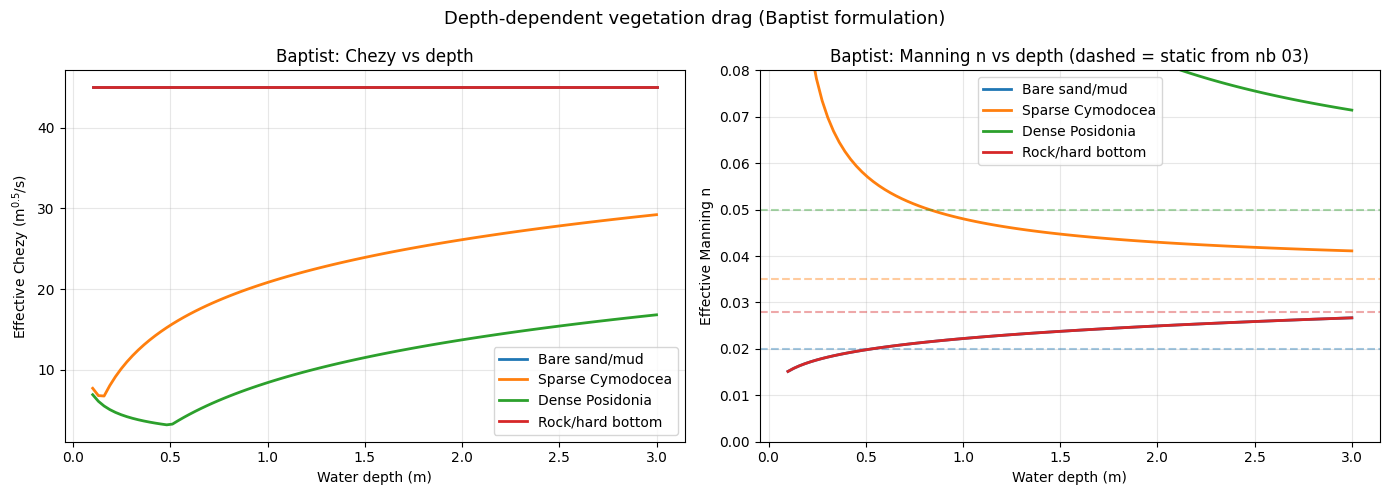


Key insight: at h=1.0 m (typical Stagnone depth):
  Bare sand/mud       : n_baptist=0.0222  n_static=0.020
  Sparse Cymodocea    : n_baptist=0.0480  n_static=0.035
  Dense Posidonia     : n_baptist=0.1188  n_static=0.050
  Rock/hard bottom    : n_baptist=0.0222  n_static=0.028


In [19]:
def baptist_chezy(h, h_v, m, D, C_D, C_bed=45.0, kappa=0.41, g=9.81):
    """Baptist (2007) effective Chezy roughness for submerged vegetation.
    
    Parameters
    ----------
    h : float or array — water depth (m)
    h_v : float — vegetation height (m)
    m : float — stem density (stems/m²)
    D : float — stem diameter (m)
    C_D : float — drag coefficient
    C_bed : float — bed Chezy without vegetation (m^0.5/s)
    """
    if h_v == 0 or m == 0:
        return C_bed * np.ones_like(h, dtype=float)
    
    h = np.asarray(h, dtype=float)
    C_b = np.where(
        h > h_v,
        # Submerged: Baptist Eq. 6
        C_bed / np.sqrt(1 + C_D * m * D * h_v / (2 * g) * C_bed**2) \
            + np.sqrt(g) / kappa * np.log(h / h_v),
        # Emergent: simplified high-drag regime
        C_bed / np.sqrt(1 + C_D * m * D * h / (2 * g) * C_bed**2)
    )
    return C_b


def chezy_to_manning(C, h):
    """Convert Chezy to Manning: n = h^(1/6) / C."""
    return np.where(C > 0, h**(1/6) / C, 0.1)


# --- Demonstrate depth-dependent roughness ---
depths = np.linspace(0.1, 3.0, 100)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for _, row in veg_params.iterrows():
    C = baptist_chezy(depths, row['h_v'], row['m'], row['D'], row['C_D'])
    n = chezy_to_manning(C, depths)
    ax1.plot(depths, C, label=row['name'], linewidth=2)
    ax2.plot(depths, n, label=row['name'], linewidth=2)
    # Static Manning for reference
    ax2.axhline(row['manning_static'], color=ax2.get_lines()[-1].get_color(),
                linestyle='--', alpha=0.4)

ax1.set_xlabel('Water depth (m)'); ax1.set_ylabel('Effective Chezy (m$^{0.5}$/s)')
ax1.set_title('Baptist: Chezy vs depth'); ax1.legend(); ax1.grid(alpha=0.3)

ax2.set_xlabel('Water depth (m)'); ax2.set_ylabel('Effective Manning n')
ax2.set_title('Baptist: Manning n vs depth (dashed = static from nb 03)')
ax2.legend(); ax2.grid(alpha=0.3); ax2.set_ylim(0, 0.08)

fig.suptitle('Depth-dependent vegetation drag (Baptist formulation)', fontsize=13)
fig.tight_layout()
plt.savefig(str(fig_dir / 'baptist_roughness_vs_depth.png'), dpi=150, bbox_inches='tight')
plt.show()

print('\nKey insight: at h=1.0 m (typical Stagnone depth):')
for _, row in veg_params.iterrows():
    C = baptist_chezy(1.0, row['h_v'], row['m'], row['D'], row['C_D'])
    n = chezy_to_manning(C, 1.0)
    print(f'  {row["name"]:20s}: n_baptist={n:.4f}  n_static={row["manning_static"]:.3f}')

### 4.1 Generate Trachytopes Configuration Files

Delft3D FM uses two files for trachytopes:
- `.ttd` — trachytope definitions (vegetation properties per class)
- `.arl` — spatial distribution (which class at each grid cell)

Alternative: use `initialFields.ini` with the Baptist module directly.

In [20]:
def write_trachytope_def(filepath, veg_params_df):
    """Write a Delft3D trachytope definition file (.ttd).
    
    Format: class_id  formula_nr  param1  param2  param3  param4
    Formula 51 = Baptist: h_v, m*D, C_D, C_bed
    Formula 1  = constant Manning
    """
    with open(filepath, 'w') as f:
        f.write('* Trachytope definitions for Stagnone DT\n')
        f.write('* Generated from satellite-derived seagrass classification\n')
        f.write('* class  formula  param1    param2    param3    param4\n')
        for _, row in veg_params_df.iterrows():
            cls = int(row['class'])
            if row['h_v'] > 0 and row['m'] > 0:
                # Baptist formula (type 51 in Delft3D)
                nD = row['m'] * row['D']  # stem density * diameter
                f.write(f'  {cls}    51    {row["h_v"]:.3f}    {nD:.3f}    {row["C_D"]:.2f}    45.0\n')
            else:
                # Constant Manning (type 1)
                f.write(f'  {cls}     1    {row["manning_static"]:.4f}\n')
    print(f'Written: {filepath}')


# Generate .ttd file
ttd_path = model_dir / 'trachytopes.ttd'
write_trachytope_def(ttd_path, veg_params)

print('\nTo activate in the MDU:')
print('  [Trachytopes]')
print('  trtRou = Y')
print('  trtDef = trachytopes.ttd')
print('  trtL   = trachytopes.arl')
print('  dtTrt  = 600.0')

Written: C:\Users\Unipa\Documents\StagnoneDT\model\dflowfm_v03c\trachytopes.ttd

To activate in the MDU:
  [Trachytopes]
  trtRou = Y
  trtDef = trachytopes.ttd
  trtL   = trachytopes.arl
  dtTrt  = 600.0


---
## 5. Summary and Next Steps

| Method | Status | Accuracy | Key Advantage |
|--------|--------|----------|---------------|
| Notebook 01_input_satellite_roughness threshold | Baseline | ~72% (estimated) | No training data needed |
| **Method 1: RF + Lyzenga WCC** | Prototype ready | ~82-90% (literature) | Water column removed, ML-based |
| **Method 2: PlanetScope composite** | Awaiting data | Expected 85%+ | 3m resolution, seasonal dynamics |
| **Method 3: Baptist trachytopes** | Config ready | N/A (physics-based) | Depth-dependent drag, tide-adaptive |

### Immediate actions:
1. Digitize training polygons in QGIS (replace placeholder regions in cell 2.3)
2. Request PlanetScope time series (Jun-Sep 2024) via institutional access
3. Activate existing roughness in v03a (`initialFields.ini`) as baseline test
4. Run v03a with trachytopes `.ttd` as sensitivity experiment

### Publication potential:
- **Gap identified in literature**: no paper completes the full pipeline
  satellite image → friction map → validated 3D hydrodynamic simulation
- Stagnone is ideal: shallow, clear water, well-studied seagrass species
- Target journal: Remote Sensing of Environment or Ecological Modelling